In [1]:
import torch
import MyRCNN
model = MyRCNN.Model()
model.eval()
for tensor, label in model.loader:
    onnx_prog = torch.onnx.export(model, tensor)
# onnx_prog.save(destination="myrcnn.onnx")

/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/wanderer2414/MyRCNN/config.py:65: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/wanderer2414/MyRCNN/config.py:75: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/home/wanderer2414/MyRCNN/config.py:78: UserWarning: Argument(s) 'mode, cval' are not valid for transform Affine
  A.Affine(shear=15, p=0.5, mode=cv2.BORDER_CONSTANT, cval=0), # Updated from deprecated IAAAffin

[torch.onnx] Obtain model graph for `Model([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Model([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/torch/export/_unlift.py:825: UserWarning: A model attribute `model.color.downgrade.0.weight` requires gradient. but it's not properly registered as a parameter. torch.export will detach it and treat it as a constant tensor but please register it as parameter instead.
  unlift_gm = _create_stateful_graph_module(new_gm, ep.range_constraints, ep)
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/torch/export/_unlift.py:825: UserWarning: A model attribute `model.color.interpolate.0.0.0.weight` requires gradient. but it's not properly registered as a parameter. torch.export will detach it and treat it as a constant tensor but please register it as parameter instead.
  unlift_gm = _create_stateful_graph_module(new_gm, ep.range_constraints, ep)
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/torch/export/_unlift.py:825: UserWarning: A model attribute `model.color.interpolate.0.1.0.weight` requires gr

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ❌


ConversionError: Failed to convert the exported program to an ONNX model. [96mThis is step 3/3[0m of exporting the model to ONNX. Next steps:
- If there is a missing ONNX function, implement it and register it to the registry.
- If there is an internal error during ONNX conversion, debug the error and submit a PR to PyTorch.
- Create an error report with `torch.onnx.export(..., report=True)`, and save the ExportedProgram as a pt2 file. Create an issue in the PyTorch GitHub repository against the [96m*onnx*[0m component. Attach the error report and the pt2 model.

## Exception summary

<class 'torch.onnx._internal.exporter._errors.DispatchError'>: No ONNX function found for <OpOverload(op='aten.mode', overload='default')>. Failure message: No decompositions registered for the real-valued input
⬆️
<class 'torch.onnx._internal.exporter._errors.ConversionError'>: Error when translating node %mode : [num_users=1] = call_function[target=torch.ops.aten.mode.default](args = (%view, 2), kwa

In [ ]:
import MyRCNN
import torch
model = MyRCNN.Model(train_loader, test_loader, len(config.PASCAL_CLASSES), device=torch.device("cpu"))
x : torch.Tensor

# x, y = train_data[1]
# file = torch.onnx.export(model.model, args=(x))

NameError: name 'train_loader' is not defined

In [ ]:

# from torch import stack
# import torch
# from torch import Tensor
# def nms(boxes: Tensor)->Tensor:
#     N = boxes.shape[0]
#     rows, cols = torch.meshgrid(torch.arange(N, device=boxes.device), torch.arange(N, device=boxes.device), indexing='ij')
    
#     boxes1 = boxes.unsqueeze(1).expand(N, N, 4)
#     boxes2 = boxes.unsqueeze(0).expand(N, N, 4)
#     x1 = torch.max(boxes1[:, :, 0], boxes2[:, :, 0])
#     x2 = torch.min(boxes1[:, :, 2], boxes2[:, :, 2])
#     w = x2 - x1
#     del x1, x2
#     y1 = torch.max(boxes1[:, :, 1], boxes2[:, :, 1])
#     y2 = torch.min(boxes1[:, :, 3], boxes2[:, :, 3])
#     h = y2-y1
#     del y2, y1
#     s = ((boxes[:, 2]-boxes[:, 0])*(boxes[:, 3] - boxes[:, 1]))
#     s = s.unsqueeze(1).expand(N, N) + s.unsqueeze(0).expand(N, N)
#     intersect = w*h
#     IoU = intersect/(s - intersect)
#     IoU = IoU * (rows>cols)
#     cond = IoU > 0.9
#     indices = (cond.any(dim=1).logical_not())
    
#     return boxes[indices]

In [ ]:
import MyRCNN
import torch
from torch import device, load, Tensor, tensor
from torch.nn.functional import pad, unfold
import matplotlib.pyplot as plt
import matplotlib.patches as pat

model = MyRCNN.Model(device("cpu"))
model.model.load_state_dict(load("bbx.pth", map_location="cpu"))
# model.cls.load_state_dict(load("cls.pth", map_location="cpu"))

def count_parameters(model):
        return sum(p.numel() for p in model.parameters())

print(count_parameters(model.cls))
# x = dt.getTrainTensor(0)
# x = x[:, :, 0:350, 250:600]

# prep = model.model.color.prepare(x)
# mask, color, result = model.model(x)
# boxes = dt.getTrainLabel(0)[:, 1:]
# res = model.cls(mask, color, boxes)


# x = result[0]
# x = x.repeat(1, 3, 1, 1)
# # print(x.min(), x.max())
# x = x-x.min()
# x = x/x.max()
# boxes = result[1].squeeze(0)
# box = boxes[0, :]
# cls, x1, y1, x2, y2 = box.detach().long().numpy()
# # x1 = x1 + 50
# # x2 = x2 - 100
# # y1 = (y1+30)
# boxes = boxes[:, 1:]
# boxes = nms(boxes)
# for box in boxes:
#     x1, y1, x2, y2 = box.detach()
#     rect  = pat.Rectangle((x1, y1), x2, y2, facecolor='none', edgecolor='red')
#     plt.subplot().add_patch(rect)
# # x[:, 0, y2, x1:x2] = 1
# # x[:, 1, y2, x1:x2] = 0
# # x[:, 2, y2, x1:x2] = 0
# Gx = tensor(
#             [[0, -1, 0],
#              [-1, 4, -1],
#              [0, -1, 0]], dtype=torch.float
#         ).view(1, 1, 3, 3).expand(3, 1, 3, 3)

# Gy = torch.tensor([[-1, -2, -1],
#              [ 0,  0,  0],
#              [ 1,  2,  1]], dtype=torch.float).view(1, 1, 3, 3).expand(3, 1, 3, 3)
# Gx = torch.conv2d(x, Gx, padding=1, stride=1, groups=3)
# Gy = torch.conv2d(x, Gy, padding=1, stride=1, groups=3)
# x = (Gx * Gx + Gy * Gy).sqrt()
# x = Gx * x
# x = x.sum(dim=1, keepdim=True)
# x = x - x.min()
# x = x/x.max()
# x = x.repeat(1, 3, 1, 1)
# img = TensorToImg(x.detach())
# ImgWrite("result.png", img)
# ImgWrite("sobel.png", img)
# plt.imshow(img)

109536


In [ ]:
# from torch import Tensor, where, zeros_like
# from torch.nn.functional import pad, unfold
# def highest_pool2d(x, kernel_size=3, stride=1, padding=0) -> Tensor:
#     if padding > 0:
#         x = pad(x, (padding, padding, padding, padding), mode="reflect")
#     B, C, H, W = x.shape
#     patches = unfold(x, kernel_size=kernel_size, stride=stride)
#     patches = patches.view(B, C, kernel_size * kernel_size, -1)
#     M = patches.max(dim=2, keepdim=True).values
#     patches = patches[:, :, 0:1, :] - M
#     patches[patches == 0] = M[patches==0]
#     patches[patches < 0] = 0
#     H_out = (H - kernel_size) // stride + 1
#     W_out = (W - kernel_size) // stride + 1
#     return patches.view(B, C, H_out, W_out)

In [ ]:

from torch import stack
import torch
def nms(boxes: Tensor)->Tensor:
    N = boxes.shape[0]
    rows, cols = torch.meshgrid(torch.arange(N, device=boxes.device), torch.arange(N, device=boxes.device), indexing='ij')
    
    boxes1 = boxes.unsqueeze(1).expand(N, N, 4)
    boxes2 = boxes.unsqueeze(0).expand(N, N, 4)
    x1 = torch.max(boxes1[:, :, 0], boxes2[:, :, 0])
    x2 = torch.min(boxes1[:, :, 2], boxes2[:, :, 2])
    w = x2 - x1
    del x1, x2
    y1 = torch.max(boxes1[:, :, 1], boxes2[:, :, 1])
    y2 = torch.min(boxes1[:, :, 3], boxes2[:, :, 3])
    h = y2-y1
    del y2, y1
    s = ((boxes[:, 2]-boxes[:, 0])*(boxes[:, 3] - boxes[:, 1]))
    s = s.unsqueeze(1).expand(N, N) + s.unsqueeze(0).expand(N, N)
    intersect = w*h
    IoU = intersect/(s - intersect)
    IoU = IoU * (rows>cols)
    cond = IoU > 0.9
    indices = (cond.any(dim=1).logical_not())
    
    return boxes[indices]

In [ ]:
import matplotlib.pyplot as plt
import torch
import matplotlib.patches as patches
from torch import Tensor, arange, float as tfloat, topk, zeros_like,stack, tensor, device
from torch.nn.functional import sigmoid, conv2d, relu, avg_pool2d, interpolate, softmax
from torchvision.ops import roi_align
import gc
gc.collect()
i = 7
x: Tensor = dt.getTrainTensor(i).to(device=device("cuda"))
mask = model.model.mask(x)
color = model.model.color(x)
x1, y1, x2, y2,cls_gt = dt.getTrainLabel(i).squeeze(0)
boxes = tensor([[x1,y1,x2,y2]], device=x.device)
crop_mask = roi_align(mask, [boxes], (50, 10))

cls = softmax(model.cls(mask, color, boxes), dim=-1)
print(f"Min: {cls.min()}, Max: {cls.max()} Groundtruth class:{cls_gt}, percent: {cls[0][cls_gt.long()]}, max score: {cls.max(dim=-1).indices.detach().cpu().numpy()}")
x = mask
x = crop_mask
# x = model.cls.boundary_score[0](x)
# x= model.cls.boundary_score[1](x)
# x= model.cls.boundary_score[2](x)
# x= model.cls.boundary_score[3](x)
# x= model.cls.boundary_score[4](x)
# x= model.cls.boundary_score[5](x)
# x= model.cls.boundary_score[6](x)
# x= model.cls.boundary_score[7](x)
# x= model.cls.boundary_score[8](x)
# x= model.cls.boundary_score[9](x)
# x= model.cls.boundary_score[10](x)
# x= model.cls.boundary_score[11](x)
# x= model.cls.boundary_score[12](x)
# x= model.cls.boundary_score[13](x)
# x= model.cls.boundary_score[14](x)
# x= model.cls.boundary_score[15](x)
# x= model.cls.boundary_score[16](x)
# x= model.cls.boundary_score[17](x)
# x= model.cls.boundary_score[18](x)
# x= model.cls.boundary_score[19](x)
# x = x[:, 0:1, :, :]
x = x.repeat(1, 3, 1, 1)
print(dt.getTrainLabel(i))
x = x-x.min()
x = x/x.max()
plt.imshow(TensorToImg(x.detach().cpu()))

NameError: name 'model' is not defined

Min 0.0, Max 11.865617752075195
torch.Size([180, 4])
tensor([180.,   0., 640., 208.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([562.,   0., 640., 366.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([556.,   0., 640., 382.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([  0.,   0., 492., 426.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([596.,   0., 640., 430.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([588.,   0., 640., 434.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([618.,   0., 640., 436.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([318.,  20., 640., 478.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([370.,  91., 640., 479.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([272.,  95., 640., 479.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([  0., 175., 576., 479.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([  0., 285., 428., 479.], device='cuda:0', grad_fn=<UnbindBackward0>)
tensor([  0., 363., 314

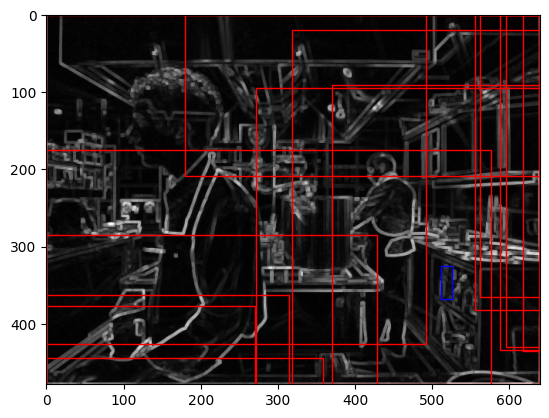

In [ ]:
import matplotlib.pyplot as plt
import torch
import matplotlib.patches as patches
from torch import Tensor, arange, float as tfloat, topk, zeros_like,stack
from torch.nn.functional import sigmoid, conv2d, relu, avg_pool2d, interpolate
import gc
gc.collect()
i = 8
x: Tensor = dt.getTrainTensor(i).to(device=device("cuda"))
H, W = x.shape[-2:]
mask, color, result = model.model(x)
score = result[0][:, 0:1, :, :]
feat = model.model.feat(mask, color)
prep = model.model.color.prepare(x)
downgrade = model.model.color.downgrade(prep)
x = mask
print(f"Min {x.min().detach().cpu().numpy()}, Max {x.max().detach().cpu().numpy()}")
x = x - x.min()
x = x/x.max() 
x = x.repeat(1, 3, 1, 1)
img = TensorToImg(x.detach().cpu())
plt.imshow(img)

boxes = result[1][:, :, 1:].squeeze()
print(boxes.shape)
boxes= nms(boxes)

# from torch import cat, zeros
# from torchvision.ops import roi_align

# N = boxes.shape[0]
# boxes = cat([zeros(N, 1, device=x.device), boxes], dim=-1)
# output_size = (400, 400)
# mask_crop: Tensor = roi_align(mask, boxes, output_size)
# color_crop: Tensor = roi_align(color, boxes, output_size)
# x_crop: Tensor = roi_align(x, boxes, output_size)
# # img = TensorToImg(x_crop[10].unsqueeze(0).detach().cpu())
# # plt.imshow(img)
# boxes = boxes[:, 1:]
for box in boxes:
    x1, y1, x2, y2 = box.detach().cpu()
    print(box)
    rect = patches.Rectangle((x1, y1), x2-x1,y2-y1, facecolor='none', edgecolor='red')
    plt.subplot().add_patch(rect)

x1, y1, x2, y2, cls = dt.getTrainLabel(i).squeeze()
print(dt.getTrainLabel(i).squeeze())
rect = patches.Rectangle((x1, y1), x2-x1,y2-y1, facecolor='none', edgecolor='blue')
plt.subplot().add_patch(rect)

In [ ]:
B, C, H, W = x.shape
Y = arange(H, dtype=tfloat, device=x.device).view(1, 1, H, 1).expand(B, 1, H, W).reshape(B, -1, 1)
X = arange(W, dtype=tfloat, device=x.device).view(1, 1, 1, W).expand(B, 1, H, W).reshape(B, -1, 1)
bbx_flat = x[:, 0:1, :, :].reshape(B, -1, 1)
# print(bbx_flat[0, 2, 0], x[0, 0, 0, 2])
indices = topk(bbx_flat, 10, dim=1).indices
values = topk(bbx_flat, 10, dim=1).values
mask = zeros_like(bbx_flat)
indices = mask.scatter(1, indices, True).bool()
print(Y[indices], X[indices])
# print(x[0, 0, Y[indices][2].long(), X[indices][2].long()])
print(values)
# indices = zeros_like(bbx_flat).scatter(1, indices, True)
# print(indices)
# print(x[:, :, Y[0, 2, 0].long(), X[0, 2, 0].long()], bbx_flat[0, 2, 0])

tensor([270., 270., 270., 270., 271., 271., 271., 272., 272., 272.],
       device='cuda:0') tensor([82., 83., 84., 85., 83., 84., 85., 83., 84., 85.], device='cuda:0')
tensor([[[1.0000],
         [1.0000],
         [1.0000],
         [1.0000],
         [1.0000],
         [1.0000],
         [1.0000],
         [1.0000],
         [1.0000],
         [0.9918]]], device='cuda:0')


In [ ]:
from torch import arange, tensor, float as tfloat, device
label = dt.getTrainLabel(0).unsqueeze(0).to(device=device("cuda"))
label = label.squeeze().squeeze()
X1, Y1, X2, Y2 = label[0:4]
X1 = X1.floor().long()
X2 = X2.ceil().long()
Y1 = Y1.floor().long()
Y2 = Y2.ceil().long()
scores = model.model(dt.getTrainTensor(0).to(device=device("cuda")))
B, C, H, W = scores.shape
score = scores[:, 0:1, :, :]
w = scores[:, 1:2, :, :]
h = scores[:, 2:3, :, :]
row = arange(H, device=label.device, dtype=tfloat).view(1,1,H,1).expand(1,1,H,W)
col = arange(W, device=label.device, dtype=tfloat).view(1,1,1,W).expand(1,1,H,W)
x1 = (col-w).floor()
x2 = (col+w).ceil()
y1 = (row-h).floor()
y2 = (row+h).ceil()
pred_box = score[:, :, Y1:Y2, X1:X2]
center = tensor([(X1+X2)/2, (Y1+Y2)/2], device=label.device, dtype=tfloat).view(2, 1, 1, 1, 1).expand(2, 1,1,H,W)
distance = ((row-center[1]).square() + (col-center[0]).square()).sqrt()
print(distance.min(), distance.max(), distance.mean())
target = distance[:, :, Y1:Y2, X1:X2]
target = 1-target/target.max()
target[target<0.8] = 0
target = target.repeat(1, 3, 1, 1)
import matplotlib.pyplot as plt
plt.imshow(TensorToImg(target.detach().to(device("cpu"))))
plt.show()


AttributeError: 'tuple' object has no attribute 'shape'

In [ ]:

import torch
def pool2d(x, kernel_size=3, stride=1, padding=0) -> torch.Tensor:
    if padding > 0:
        x = torch.nn.functional.pad(x, (padding, padding, padding, padding), mode="reflect")
    B, C, H, W = x.shape
    patches = torch.nn.functional.unfold(x, kernel_size=kernel_size, stride=stride)
    patches = patches.view(B, C, kernel_size * kernel_size, -1)
    median = patches.mode(dim=2).values
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    return median.view(B, C, H_out, W_out)

def count(x, kernel_size=3, stride=1, padding=0) -> torch.Tensor:
    if padding > 0:
        x = torch.nn.functional.pad(x, (padding, padding, padding, padding), mode="reflect")
    B, C, H, W = x.shape
    weight = torch.tensor([256*256, 256, 1], device=x.device).view(1, 3, 1, 1)
    x = (x* weight).sum(dim=1, keepdim=True)
    patches = torch.nn.functional.unfold(x, kernel_size=kernel_size, stride=stride)
    patches = patches.permute(0, 2, 1)
    count = patches.mode(dim=-1, keepdim=True).values
    print(count.shape, patches.shape)
    count = (patches[:, :]==count[:, :]).sum(dim=-1)
    
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    return count.view(B, 1, H_out, W_out)

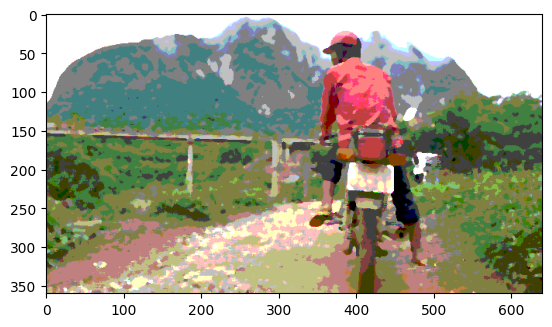

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
x = dt.getTrainTensor(0).to(device=torch.device("cuda"))
x = ((x*255/64).round()*64).clamp(max=255)/255
# c = count(x, 5, 1, 2).repeat(1, 3, 1, 1)
# x = c/c.max()
x = pool2d(x, 5, 1, 2)
# x = x/x.max()
plt.imshow(TensorToImg(x.detach().to(torch.device("cpu"))))
plt.show()

torch.Size([1, 3, 402, 768])
tensor([[359.1700, 146.1700, 471.6200, 359.7400,   4.0000]])


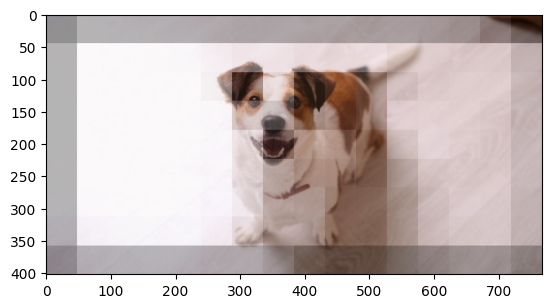

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
x = ImgToTensor(ImgRead("image2.png"))
print(x.shape)
# x = dt.getTrainTensor(0).to(device=torch.device("cpu"))
print(dt.getTrainLabel(0))
# score: Tensor = model.model(x)
B, C, H, W = x.shape
percent = 1
size = 3
# score = torch.zeros_like(x)
# for i in range(5):
#     color = torch.nn.functional.avg_pool2d(x, kernel_size=size, stride=size, padding=size//2)
#     color = torch.nn.functional.interpolate(color, size=(H, W), mode="nearest")
#     # color = (color- x).abs()
#     # color = 1 - color/color.max()
#     score = score + color
#     percent*=1.5
    # size*=3
# color = torch.nn.functional.avg_pool2d(x, kernel_size=25, stride=1, padding=12)
# color = torch.nn.functional.interpolate(color, size=(H, W), mode="nearest")
# color = (color- x).abs()
# x = score
color = x
color = torch.nn.functional.avg_pool2d(x, kernel_size=50, stride=50, padding=25)
color = torch.nn.functional.interpolate(color, size=(H, W), mode="nearest")
x = color + x
x = x-x.min()
x = x/x.max()
# x=score/score.max()
plt.imshow(TensorToImg(x.to(torch.device("cpu"))))
plt.show()
# for mat in ls:
#     mat = torch.softmax(mat, dim=-1)
#     side *= 5
#     M, I = mat.max(dim=-1)
#     indices = (M > 0.6) & (I>0)
#     H, W = mat.shape[1:3]
#     row = torch.arange(H, device=x.device).view(1, H, 1).expand(1, H, W)
#     col = torch.arange(W, device=x.device).view(1, 1, W).expand(1, H, W)
#     # print(mat.shape)
#     label = mat[:, :, :, 4]
#     print(I[indices], M[indices])
#     position = torch.stack([row, col], dim=-1)[indices].to(device=device("cpu"))
#     for i in position:
#         rect = patches.Rectangle([i[1]*side,i[0]*side], side, side, edgecolor='red', facecolor='none')
#         plt.subplot().add_patch(rect)
# plt.show()s
